# Refactor histogram, binning of MNase-seq data
February 13, 2024

Upon realization that the MOSEK solver in cvxpy allows for fast optimization for higher resolutions. It has become clear that deconvolving the chromatin at higher resolutions becomes possible.

However, in order to take advantage of these higher resolutions, the data will need to be blurred prior to binning. Currently there is not a way to do that easily. So, the task here is to create an exact histogram/img of the chromatin data, blur appropriate, then bin/downscale to the desired resolution for deconvolution.

### Tasks
1. Create an exact histogram of the MNase-seq data
2. Blur the histogram appropriately
3. Identify the +1 nucleosome location and center our histogram around this location
    - Subset the histogram and define the genomic span for this updated region.
4. Normalize the data
5. Bin/downscale to the appropriate resolution

### Notes
- Where do we normalize the data?
    - Before or after blurring?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [30]:

def create_exact_bins(chromatin_model):
    xbins = np.arange(*chromatin_model.mnase_span)
    ybins = np.arange(0, 225)

    n = len(chromatin_model.timepoints)

    # Bin histogram is one less than the bin definitions because the bins include the outer edges
    # of the bins
    exact_bins = np.zeros((n, len(ybins)-1, len(xbins)-1))

    for time_idx in range(n):

        sample = chromatin_model.timepoints[time_idx]

        plotting_reads, hist, \
            x_edges, y_edges = chromatin_model.compute_bin_counts_sample(sample, xbins, ybins)
        hist = hist.T
        exact_bins[time_idx] = hist
    return exact_bins

In [31]:
exact_bins = create_exact_bins(chromatin_model)

In [33]:
# Next smooth the exact bins

In [52]:
from scipy.signal import convolve2d
from src.preprocessing import create_2d_gaussian_kernel

def smooth_exact_bins(chromatin_model, exact_bins, k_size=20, k_sigma=0.75):
    
    g_kernel = create_2d_gaussian_kernel(k_size=k_size, sigma=k_sigma, plot=False)

    smooth_bins = exact_bins.copy()

    for i in range(exact_bins.shape[0]):
        cur_exact_hist = exact_bins[i]
        smooth_bins[i] = convolve2d(cur_exact_hist, g_kernel, mode='same')
    return smooth_bins

In [53]:
smooth_bins = smooth_exact_bins(chromatin_model, exact_bins)

In [99]:
# Now downsample to the appropriate window and resolution

# Currently a -1000, +1000 window
# Downscale to -300 + 500 approximately

# Or some iteration of nucleosme width, we started with 80 previously
# let's try 20


# 20 width bins
# (+25 bins) * (20 width) = 500 bp  gene body
# (-15 bins) * (20 width) = -300 bp promoter

new_span = chromatin_model.computed_plus_one-300, chromatin_model.computed_plus_one+500

# Next we will define our new bin locations
bin_width = 20
x_bins = np.arange(new_span[0], new_span[1], bin_width)

# And for y lengths
bin_height = 20

y_bins = np.arange(0, 240, bin_height)

# Now we will loop through each x and y bin to aggregate the counts to 
# create our new downsampled histogram
downscaled_bins = np.zeros((smooth_bins.shape[0], len(y_bins), len(x_bins)))

from src.coordinate_translator import CoordinateTranslator

# Translate from the selected mnase span to np array space
coord_translator = CoordinateTranslator(chromatin_model.mnase_span)

for x_ind in range(1, len(x_bins)):
    for y_ind in range(1, len(y_bins)):
        x_start = coord_translator.translate(x_bins[x_ind-1])
        x_end = coord_translator.translate(x_bins[x_ind])
        y_start = y_bins[y_ind-1]
        y_end = y_bins[y_ind]
        
        bin_counts = smooth_bins[0][y_start:y_end, x_start:x_end].sum()
        downscaled_bins[0][y_ind-1][x_ind-1] = bin_counts


In [105]:
exact_extent = [chromatin_model.mnase_span[0], chromatin_model.mnase_span[1],
                0, 225]

gene_extent = [new_span[0], new_span[1],
                0, 225]


([], [])

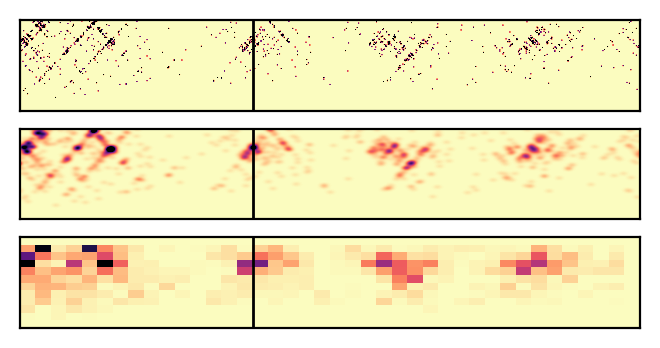

In [116]:
plt.figure(figsize=(4, 2))
plt.subplot(3, 1, 1)
plt.imshow(exact_bins[0], cmap='magma_r', vmax=0.25, origin='lower', aspect='auto',
          extent=exact_extent)
plt.xlim(new_span)
plt.yticks([])
plt.xticks([])
plt.axvline(chromatin_model.computed_plus_one, c='black', lw=1)

plt.subplot(3, 1, 2)
plt.imshow(smooth_bins[0], cmap='magma_r', vmax=0.25, origin='lower', aspect='auto',
          extent=exact_extent)
plt.xlim(new_span)
plt.yticks([])
plt.xticks([])
plt.axvline(chromatin_model.computed_plus_one, c='black', lw=1)

plt.subplot(3, 1, 3)
plt.imshow(downscaled_bins[0], cmap='magma_r', vmax=50, origin='lower', aspect='auto',
          extent=gene_extent)
plt.axvline(chromatin_model.computed_plus_one, c='black', lw=1)
plt.yticks([])
plt.xticks([])
